# Частина 1. Кластеризація методом K-Means

У цій частині ми згенеруємо штучні дані з кількома кластерами, запустимо алгоритм K-Means, візуалізуємо результат і оцінимо якість кластеризації.

K-Means — це алгоритм, який автоматично розбиває набір точок на k груп (кластерів). Він працює ітеративно: спочатку випадково обирає k центрів, потім кожну точку приписує до найближчого центру, потім перераховує центри як середнє арифметичне точок у кожній групі — і так по колу, поки центри не перестануть рухатися.
## Генерація даних

Спочатку створимо дані, де ми заздалегідь знаємо, скільки кластерів є. Це дозволить перевірити, чи алгоритм знайшов правильну структуру.

## Крок 1. Імпортуємо бібліотеки

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Щоб графіки показувались прямо в ноутбуці:
%matplotlib inline

# Налаштування для гарних графіків:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Крок 2. Створюємо штучні дані

In [10]:
# Генеруємо 300 точок, розділених на 3 кластери
X, y_true = make_blobs(
    n_samples=300,       # скільки точок
    centers=3,           # скільки кластерів
    cluster_std=0.60,    # наскільки «розмазані» кластери
    random_state=42      # фіксуємо для відтворюваності
)

# Подивимось, що вийшло:
print(f'Розмір даних: {X.shape}')       # (300, 2) — 300 точок, 2 координати
print(f'Перші 5 точок:\n{X[:5]}')       # подивимось на перші 5 рядків

Розмір даних: (300, 2)
Перші 5 точок:
[[-7.15524373 -7.39001621]
 [-7.39587521 -7.11084292]
 [-2.01567068  8.28177994]
 [ 4.50927011  2.6324358 ]
 [-8.10250191 -7.48496138]]


## Крок 3. Створюємо штучні дані

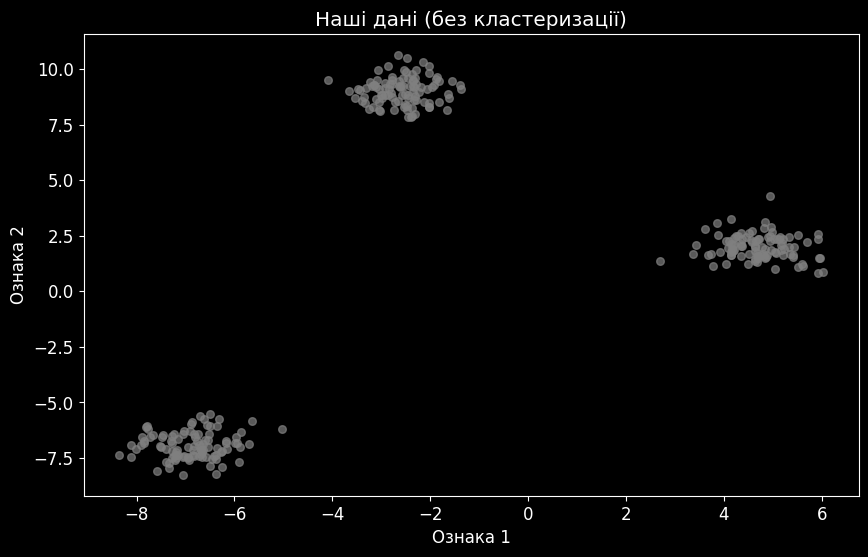

In [11]:
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.7, color='gray')
plt.title('Наші дані (без кластеризації)')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.show()

## Запускаємо K-Means

## Крок 4. Кластеризація

In [12]:
# Створюємо модель K-Means з 3 кластерами
kmeans = KMeans(
    n_clusters=3,           # кількість кластерів
    init='k-means++',       # розумна ініціалізація центрів
    random_state=42         # відтворюваність
)

# Запускаємо: алгоритм навчиться і поверне мітки кластерів
labels = kmeans.fit_predict(X)

# Подивимось результат:
print(f'Мітки кластерів: {np.unique(labels)}')  # [0, 1, 2]
print(f'Центроїди:\n{kmeans.cluster_centers_}')  # координати центрів
print(f'Інерція (J): {kmeans.inertia_:.2f}')     # сума квадратів відстаней

Мітки кластерів: [0 1 2]
Центроїди:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]
Інерція (J): 204.07


## Крок 5. Візуалізуємо результат

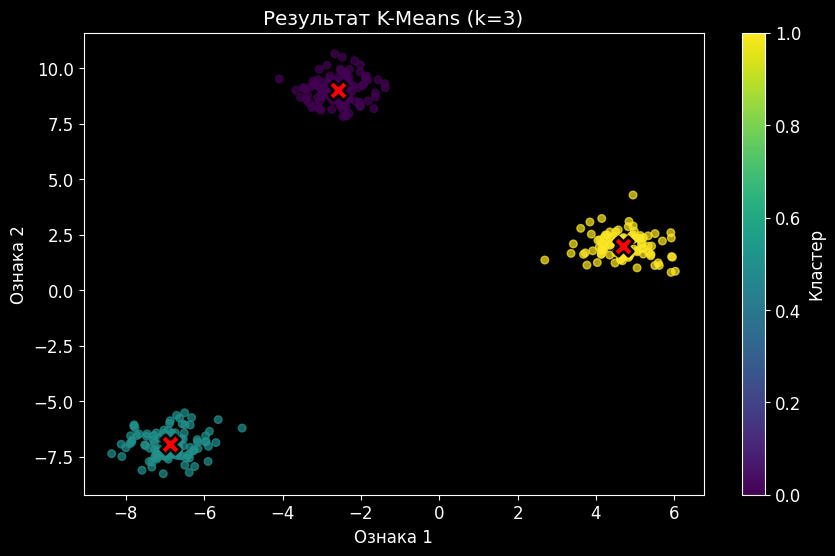

In [13]:
# Малюємо точки, розфарбовані за кластерами
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)

# Малюємо центроїди (великі червоні хрестики)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            c='red', marker='X', s=200, edgecolors='black', linewidths=2)

plt.title('Результат K-Means (k=3)')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.colorbar(label='Кластер')
plt.show()

## Крок 6. Силуетний коефіцієнт

In [14]:
score = silhouette_score(X, labels)
print(f'Силуетний коефіцієнт: {score:.3f}')

Силуетний коефіцієнт: 0.908


## Завдання 1: Експеримент з кількістю кластерів

k=2 | Силуетний коефіцієнт: 0.736
k=4 | Силуетний коефіцієнт: 0.714
k=5 | Силуетний коефіцієнт: 0.510


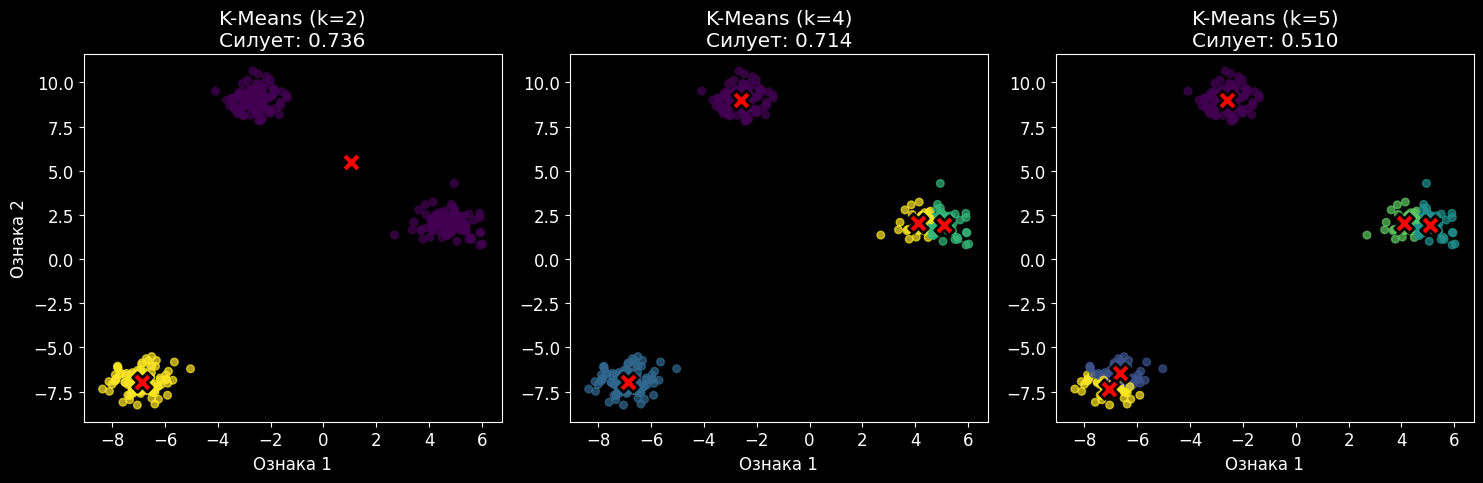

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Задаємо значення k, які хочемо перевірити
k_values = [2, 4, 5]

# Створюємо полотно для 3 графіків (1 рядок, 3 колонки)
plt.figure(figsize=(15, 5))

for i, k in enumerate(k_values):
    # 1. Навчаємо K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)

    # 2. Обчислюємо силуетний коефіцієнт
    score = silhouette_score(X, labels)
    print(f'k={k} | Силуетний коефіцієнт: {score:.3f}')

    # 3. Будуємо графік
    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X',
                s=200, edgecolors='black', linewidths=2)

    plt.title(f'K-Means (k={k})\nСилует: {score:.3f}')
    plt.xlabel('Ознака 1')
    if i == 0:
        plt.ylabel('Ознака 2')

plt.tight_layout()
plt.show()

## Висновок до Завдання 1:
Найвищий силуетний коефіцієнт спостерігається при k=3 (0.908), тоді як для k=2, 4 та 5 це значення помітно знижується. Це повністю збігається з візуальним розподілом на графіку, де чітко видно три природні "хмарки" точок. Примусове розбиття на іншу кількість кластерів (k=2, 4, 5) призводить до неприродного об'єднання окремих груп або розриву суцільних хмар, що і фіксує падіння метрики силуету.

# Частина 2. Як обрати кількість кластерів

У першій частині ми знали, що кластерів 3, бо самі їх створили. Але на реальних даних цього ніхто не знає. Тому потрібні методи для визначення оптимального k.
## Метод ліктя (Elbow Method)

Ідея проста: запускаємо K-Means для різних k (від 1 до 10), записуємо інерцію (суму квадратів відстаней) і будуємо графік. Шукаємо «лікоть» — точку, після якої інерція перестає суттєво зменшуватись.

## Крок 7. Будуємо графік ліктя

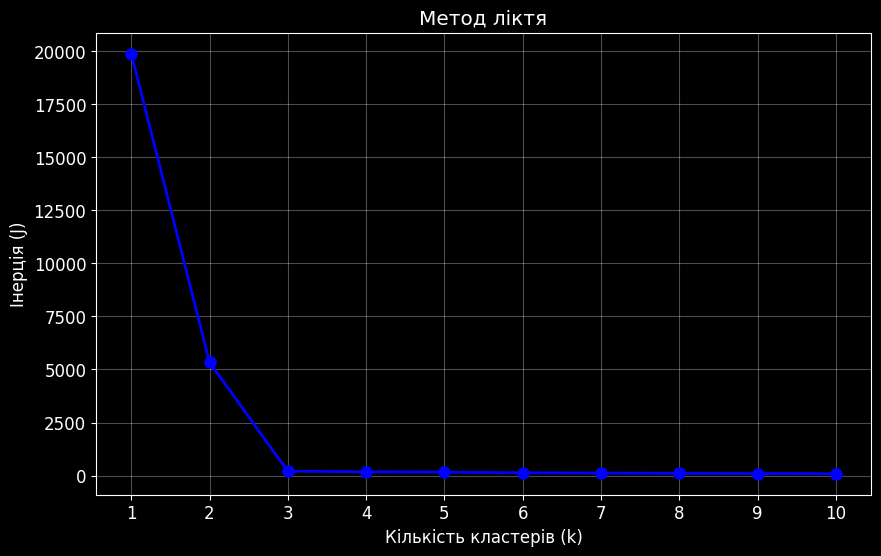

In [16]:
inertias = []
K_range = range(1, 11)  # k від 1 до 10

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція (J)')
plt.title('Метод ліктя')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

### Аналіз графіка ліктя:
На графіку ви побачите різкий злам при k=3 — це і є «лікоть». До k=3 інерція швидко падає (кожен новий кластер дає великий виграш), а після — зменшується повільно (додаткові кластери мало що дають).

## Силуетний аналіз

## Крок 8. Силует для різних k
Ще один спосіб перевірити оптимальну кількість кластерів — побудувати діаграму силуетних коефіцієнтів для кожного значення k.

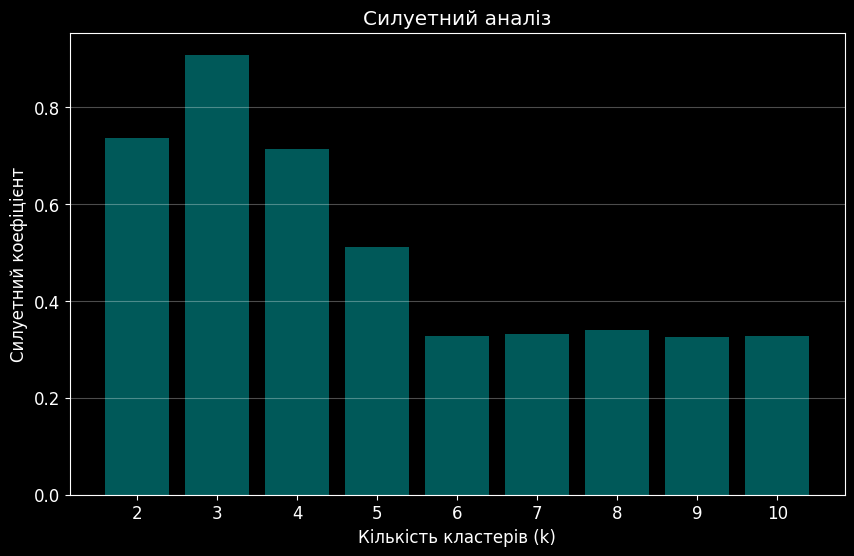

Найкращий k за силуетом: 3


In [17]:
silhouettes = []
K_range2 = range(2, 11)  # силует неможливо порахувати для k=1

for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels_k = km.fit_predict(X)
    silhouettes.append(silhouette_score(X, labels_k))

plt.bar(K_range2, silhouettes, color='teal', alpha=0.7)
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Силуетний коефіцієнт')
plt.title('Силуетний аналіз')
plt.xticks(K_range2)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

best_k = K_range2[np.argmax(silhouettes)]
print(f'Найкращий k за силуетом: {best_k}')

## Аналіз силуетного графіка:
Максимум силуету має бути при k=3 — це підтверджує результат методу ліктя. Коли обидва методи вказують на одне й те саме k — це надійний результат.

## Завдання 2: Зміна форми кластерів

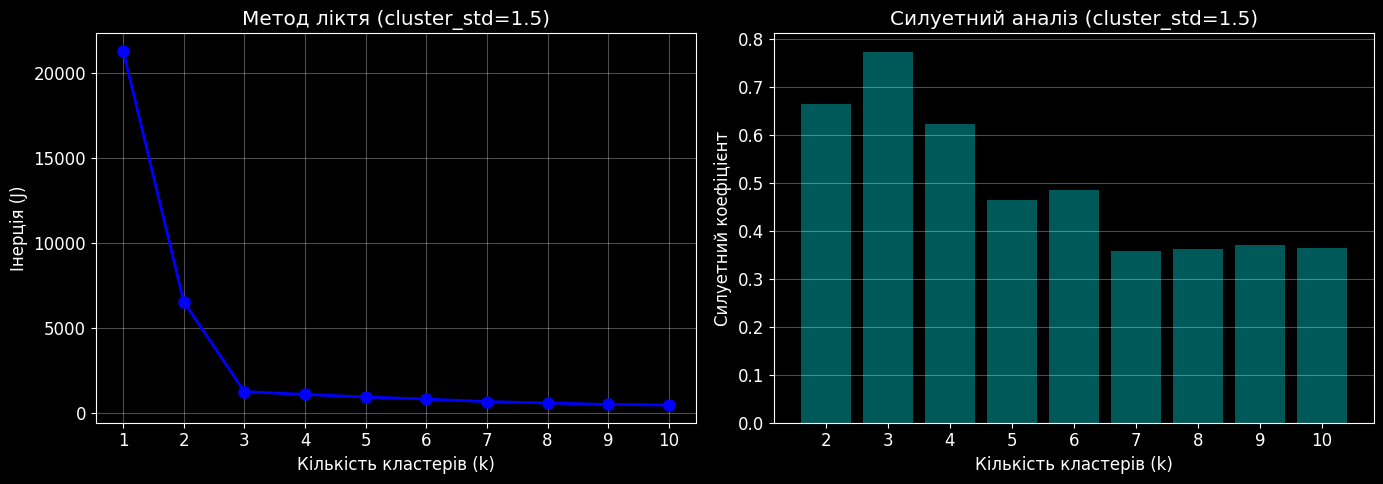

Найкращий k за силуетом для розмазаних даних: 3
Максимальний силует: 0.773


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# 1. Генеруємо нові дані з більшим "розмазуванням"
X_noisy, y_true_noisy = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.5,   # Змінили з 0.60 на 1.5
    random_state=42
)

# 2. Обчислюємо інерцію для методу ліктя
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_noisy)
    inertias.append(km.inertia_)

# 3. Обчислюємо силуетний коефіцієнт
silhouettes = []
K_range2 = range(2, 11)
for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels_k = km.fit_predict(X_noisy)
    silhouettes.append(silhouette_score(X_noisy, labels_k))

# 4. Будуємо графіки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік ліктя
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Кількість кластерів (k)')
ax1.set_ylabel('Інерція (J)')
ax1.set_title('Метод ліктя (cluster_std=1.5)')
ax1.set_xticks(K_range)
ax1.grid(True, alpha=0.3)

# Графік силуету
ax2.bar(K_range2, silhouettes, color='teal', alpha=0.7)
ax2.set_xlabel('Кількість кластерів (k)')
ax2.set_ylabel('Силуетний коефіцієнт')
ax2.set_title('Силуетний аналіз (cluster_std=1.5)')
ax2.set_xticks(K_range2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Найкращий k за силуетом для розмазаних даних: {K_range2[np.argmax(silhouettes)]}')
print(f'Максимальний силует: {max(silhouettes):.3f}')

## Висновок до Завдання 2:
Зі збільшенням параметра cluster_std до 1.5 кластери стали більш розмазаними та почали перетинатися, через що силуетний коефіцієнт знизився порівняно з попередніми результатами (впав з ~0.9 до ~0.77).

Визначити оптимальну кількість кластерів стало візуально дещо складніше, оскільки "злам" (лікоть) на графіку інерції при k=3 став трохи менш різким і вираженим, але все одно його суть не змінилася. Силуетний аналіз також показує менший розрив між значеннями для різних k, що підтверджує погіршення загальної якості кластеризації через те, що точки тепер лежать на межах різних груп.